In [1]:
# Install packages
!pip -q install bokeh_sampledata geopandas pyogrio networkx scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.7/17.7 MB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.5/542.5 kB 21.2 MB/s eta 0:00:00


In [29]:
# Import tools
import json
import shutil
import zipfile

import ee
import geopandas as gpd
import google.auth
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

from bokeh.sampledata.us_states import data as us_states
from google.colab import auth, files
from matplotlib.lines import Line2D
from pathlib import Path
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import minimum_spanning_tree
from scipy.spatial import Voronoi
from scipy.spatial.distance import cdist
from shapely.geometry import Polygon, shape
from sklearn.metrics.pairwise import nan_euclidean_distances

In [30]:
# Set plot style
plt.rc("text",usetex=False)
plt.rc("font",family="serif")
plt.rc("mathtext",fontset="cm")
plt.rc("font",size=13)
plt.rc("axes",labelsize=14)
plt.rc("xtick",labelsize=11)
plt.rc("ytick",labelsize=11)
plt.rc("legend",fontsize=9)

In [31]:
# Set protocol
PROJECT = "taps-505803"
REGION = "California"
PRIMARY = "stratified"
SEED = 7
COUNT = 100
KINDS = ["uniform","population","stratified","clustered"]
START = 2021
END = 2025
MONTHS = [6,7,8,9,10]
NEIGHBORS = 10
BANDS = 3
BUDGET = 10
MAXBUDGET = 30
K = 30
CLOCK = np.array([0,.25,.5])
HORIZON = 1.
BSCALE = .01
POOL = 5000
RAWPOOL = 7000
CLUSTERS = 8
CLUSTERSCALE = 35
PRUNE = 1e-6
ACCESS = pd.Timestamp.now(tz="UTC").date().isoformat()
OUT = Path("07-prospective-results")
WINDOWS = [f"{year}-{month:02d}" for year in range(START,END+1) for month in MONTHS]

AOD = "MODIS/061/MCD19A2_GRANULES"
ERA = "ECMWF/ERA5/HOURLY"
POP = "JRC/GHSL/P2023A/GHS_POP/2020"
ELEV = "USGS/3DEP/10m_collection"
LAND = "ESA/WorldCover/v200"
STATES = "TIGER/2018/States"

protocol = pd.DataFrame([{
    "region":REGION,
    "primary":PRIMARY,
    "candidates":COUNT,
    "candidate_types":"|".join(KINDS),
    "start_year":START,
    "end_year":END,
    "season_months":"|".join(map(str,MONTHS)),
    "windows":len(WINDOWS),
    "neighbors":NEIGHBORS,
    "regions":BANDS,
    "budget":BUDGET,
    "max_budget":MAXBUDGET,
    "K":K,
    "clock":"|".join(map(str,CLOCK)),
    "horizon":HORIZON,
    "beta_scale":BSCALE,
    "seed":SEED,
    "access_date_utc":ACCESS
}])

display(protocol.T)

,0
region,California
primary,stratified
candidates,100
candidate_types,uniform|population|stratified|clustered
start_year,2021
end_year,2025
season_months,6|7|8|9|10
windows,25
neighbors,10
regions,3


,0
region,California
primary,stratified
candidates,100
candidate_types,uniform|population|stratified|clustered
start_year,2021
end_year,2025
season_months,6|7|8|9|10
windows,25
neighbors,10
regions,3


In [32]:
# Connect Earth Engine
auth.authenticate_user()
credentials,_ = google.auth.default()
ee.Initialize(credentials=credentials,project=PROJECT)
print(ee.String("Earth Engine connected").getInfo())

Earth Engine connected


Earth Engine connected


In [33]:
# Load study sources
states = ee.FeatureCollection(STATES)
california = ee.Feature(states.filter(ee.Filter.eq("STUSPS","CA")).first())
worldcover = ee.ImageCollection(LAND).first().select("Map")
land = worldcover.neq(80).rename("land").clip(california.geometry())

popraw = ee.Image(POP).select("population_count")
population = popraw.updateMask(popraw.gte(0)).rename("population")
elevation = ee.ImageCollection(ELEV).filterBounds(california.geometry()).mosaic().select("elevation")

start = f"{START}-01-01"
end = f"{END+1}-01-01"
season = ee.Filter.calendarRange(min(MONTHS),max(MONTHS),"month")

aod = (
    ee.ImageCollection(AOD)
    .filterBounds(california.geometry())
    .filterDate(start,end)
    .filter(season)
    .select(["Optical_Depth_047","Optical_Depth_055","AOD_QA"])
)

era = (
    ee.ImageCollection(ERA)
    .filterBounds(california.geometry())
    .filterDate(start,end)
    .filter(season)
    .select([
        "temperature_2m",
        "dewpoint_temperature_2m",
        "total_precipitation",
        "surface_pressure",
        "u_component_of_wind_10m",
        "v_component_of_wind_10m"
    ])
)

eraproj = era.first().select("temperature_2m").projection()
erascale = eraproj.nominalScale().getInfo()

geometry = shape(california.geometry().getInfo())
ca = gpd.GeoDataFrame({"region":[REGION]},geometry=[geometry],crs=4326).to_crs(3310)

In [34]:
# Audit study sources
expected = sum(
    pd.Period(f"{year}-{month:02d}",freq="M").days_in_month*24
    for year in range(START,END+1)
    for month in MONTHS
)

audit = ee.Dictionary({
    "aod_count":aod.size(),
    "era_count":era.size(),
    "population_ok":population.bandNames().contains("population"),
    "elevation_ok":elevation.bandNames().contains("elevation"),
    "worldcover_ok":worldcover.bandNames().contains("Map"),
    "california_ok":ee.Algorithms.IsEqual(california.get("STUSPS"),"CA")
}).getInfo()

sources = pd.DataFrame([
    ["MAIAC AOD",AOD,"Satellite aerosol",
     audit["aod_count"],audit["aod_count"]>0,
     "https://developers.google.com/earth-engine/datasets/catalog/MODIS_061_MCD19A2_GRANULES"],

    ["ERA5 hourly",ERA,"Meteorology",
     audit["era_count"],audit["era_count"]==expected,
     "https://developers.google.com/earth-engine/datasets/catalog/ECMWF_ERA5_HOURLY"],

    ["GHSL population",POP,"Population target",
     1,audit["population_ok"],
     "https://developers.google.com/earth-engine/datasets/catalog/JRC_GHSL_P2023A_GHS_POP"],

    ["3DEP elevation",ELEV,"Static terrain",
     1,audit["elevation_ok"],
     "https://developers.google.com/earth-engine/datasets/catalog/USGS_3DEP_10m_collection"],

    ["WorldCover",LAND,"Land mask",
     1,audit["worldcover_ok"],
     "https://developers.google.com/earth-engine/datasets/catalog/ESA_WorldCover_v200"],

    ["TIGER states",STATES,"California boundary",
     1,audit["california_ok"],
     "https://developers.google.com/earth-engine/datasets/catalog/TIGER_2018_States"]
],columns=["source","asset","role","records","passed","url"])

sources["access_date_utc"] = ACCESS

display(sources[["source","records","passed"]])
print("Ground-monitor PM2.5 loaded:",False)


,source,records,passed
0,MAIAC AOD,66283,True
1,ERA5 hourly,18360,True
2,GHSL population,1,True
3,3DEP elevation,1,True
4,WorldCover,1,True
5,TIGER states,1,True


Ground-monitor PM2.5 loaded: False


,source,records,passed
0,MAIAC AOD,66283,True
1,ERA5 hourly,18360,True
2,GHSL population,1,True
3,3DEP elevation,1,True
4,WorldCover,1,True
5,TIGER states,1,True


Ground-monitor PM2.5 loaded: False


In [35]:
# Build candidate pool
static = land.addBands(population.unmask(0)).addBands(elevation.unmask(-9999))
draws = ee.FeatureCollection.randomPoints(region=california.geometry(),points=RAWPOOL,seed=SEED,maxError=1)

poolfc = (
    static.sampleRegions(collection=draws,scale=100,geometries=True,tileScale=4)
    .filter(ee.Filter.eq("land",1))
    .filter(ee.Filter.gt("elevation",-9000))
    .limit(POOL)
)

print("Raw points:",RAWPOOL)
print("Valid land points:",poolfc.size().getInfo())

Raw points: 7000
Valid land points: 5000
Raw points: 7000
Valid land points: 5000


In [36]:
# Load candidate pool
poolrows = []

for feature in poolfc.getInfo()["features"]:
    longitude,latitude = feature["geometry"]["coordinates"]
    values = feature["properties"]
    poolrows.append({
        "longitude":longitude,
        "latitude":latitude,
        "population":values["population"],
        "elevation":values["elevation"]
    })

pool = gpd.GeoDataFrame(
    poolrows,
    geometry=gpd.points_from_xy([row["longitude"] for row in poolrows],[row["latitude"] for row in poolrows]),
    crs=4326
).to_crs(3310)

pool = pool.drop_duplicates(subset=["longitude","latitude"]).reset_index(drop=True)
pool["pool"] = np.arange(len(pool))

poolaudit = pd.DataFrame({
    "metric":["candidates","unique","positive_population","minimum_elevation","maximum_elevation"],
    "value":[len(pool),pool.geometry.nunique(),pool["population"].gt(0).sum(),pool["elevation"].min(),pool["elevation"].max()]
})

display(poolaudit)

,metric,value
0,candidates,4999.000000
1,unique,4999.000000
2,positive_population,387.000000
3,minimum_elevation,-82.667679
4,maximum_elevation,3811.906250


,metric,value
0,candidates,4999.000000
1,unique,4999.000000
2,positive_population,387.000000
3,minimum_elevation,-82.667679
4,maximum_elevation,3811.906250


In [37]:
# Define candidate designs
def make(name,index):
    frame = pool.iloc[index].copy()
    frame["candidate"] = [f"{name}_{i+1:03d}" for i in range(len(frame))]
    frame["distribution"] = name
    return frame[["candidate","distribution","pool","longitude","latitude","population","elevation","geometry"]].reset_index(drop=True)

def spread(frame,count,rng):
    xy = np.column_stack([frame.geometry.x,frame.geometry.y])
    first = int(rng.integers(len(frame)))
    selected = [first]
    distance = np.sum((xy-xy[first])**2,axis=1)
    distance[first] = -1

    for _ in range(1,count):
        index = int(np.argmax(distance))
        selected.append(index)
        new = np.sum((xy-xy[index])**2,axis=1)
        distance = np.minimum(distance,new)
        distance[selected] = -1

    return np.asarray(selected)

def cluster(frame,count,rng):
    xy = np.column_stack([frame.geometry.x,frame.geometry.y])
    centers = rng.choice(len(frame),size=CLUSTERS,replace=False)
    distance = cdist(xy,xy[centers]).min(axis=1)/1000
    weight = np.exp(-.5*(distance/CLUSTERSCALE)**2)
    return rng.choice(len(frame),size=count,replace=False,p=weight/weight.sum())

def candstats(name,frame):
    xy = np.column_stack([frame.geometry.x,frame.geometry.y])
    distance = cdist(xy,xy)/1000
    np.fill_diagonal(distance,np.nan)
    nearest = np.nanmin(distance,axis=1)

    return {
        "distribution":name,
        "candidates":len(frame),
        "unique":frame.geometry.nunique(),
        "minimum_spacing_km":nearest.min(),
        "median_nearest_km":np.median(nearest),
        "median_population":frame["population"].median(),
        "mean_population":frame["population"].mean(),
        "median_elevation":frame["elevation"].median()
    }

In [38]:
# Generate candidate designs
rng0 = np.random.default_rng(SEED)
rng1 = np.random.default_rng(SEED+1)
rng2 = np.random.default_rng(SEED+2)
rng3 = np.random.default_rng(SEED+3)

uniform = rng0.choice(len(pool),size=COUNT,replace=False)
popweights = pool["population"].clip(lower=0).to_numpy(float)
populationids = rng1.choice(len(pool),size=COUNT,replace=False,p=popweights/popweights.sum())
stratified = spread(pool,COUNT,rng2)
clustered = cluster(pool,COUNT,rng3)

sets = {
    "uniform":make("uniform",uniform),
    "population":make("population",populationids),
    "stratified":make("stratified",stratified),
    "clustered":make("clustered",clustered)
}

candidateaudit = pd.DataFrame([candstats(name,frame) for name,frame in sets.items()])
display(candidateaudit.round(3))

,distribution,candidates,unique,minimum_spacing_km,median_nearest_km,median_population,mean_population,median_elevation
0,uniform,100,100,1.814,32.852,0.000,3.526,658.776
1,population,100,100,0.980,9.698,28.532,39.950,84.766
2,stratified,100,100,57.218,64.245,0.000,2.353,633.581
3,clustered,100,100,2.149,15.223,0.000,1.789,1092.800


,distribution,candidates,unique,minimum_spacing_km,median_nearest_km,median_population,mean_population,median_elevation
0,uniform,100,100,1.814,32.852,0.000,3.526,658.776
1,population,100,100,0.980,9.698,28.532,39.950,84.766
2,stratified,100,100,57.218,64.245,0.000,2.353,633.581
3,clustered,100,100,2.149,15.223,0.000,1.789,1092.800


In [39]:
# Prepare sampling sites
allsites = gpd.GeoDataFrame(pd.concat(list(sets.values()),ignore_index=True),crs=3310).to_crs(4326)
features = []

for row in allsites.itertuples():
    features.append(ee.Feature(
        ee.Geometry.Point([row.geometry.x,row.geometry.y]),
        {"candidate":row.candidate,"distribution":row.distribution}
    ))

sitefc = ee.FeatureCollection(features)
site_static = allsites[["candidate","distribution","population","elevation"]].copy()

print("Candidate rows:",len(allsites))
print("Earth Engine features:",sitefc.size().getInfo())

Candidate rows: 400
Earth Engine features: 400
Candidate rows: 400
Earth Engine features: 400


In [40]:
# Define monthly sampling
def maskaod(image):
    qa = image.select("AOD_QA")
    landqa = qa.rightShift(3).bitwiseAnd(3).eq(0)
    quality = qa.rightShift(8).bitwiseAnd(15).eq(0)
    values = image.select(["Optical_Depth_047","Optical_Depth_055"]).multiply(.001)
    return values.updateMask(landqa.And(quality)).updateMask(values.gte(0))

def monthaod(year,month):
    begin = ee.Date.fromYMD(year,month,1)
    finish = begin.advance(1,"month")
    return (
        aod.filterDate(begin,finish)
        .map(maskaod)
        .median()
        .rename(["aod047","aod055"])
    )

def monthmet(year,month):
    begin = ee.Date.fromYMD(year,month,1)
    finish = begin.advance(1,"month")
    subset = era.filterDate(begin,finish)
    means = subset.select([
        "temperature_2m",
        "dewpoint_temperature_2m",
        "surface_pressure",
        "u_component_of_wind_10m",
        "v_component_of_wind_10m"
    ]).mean()

    return (
        means.select("temperature_2m").subtract(273.15).rename("temp")
        .addBands(means.select("dewpoint_temperature_2m").subtract(273.15).rename("dew"))
        .addBands(means.select("surface_pressure").divide(1000).rename("pressure"))
        .addBands(means.select("u_component_of_wind_10m").rename("windu"))
        .addBands(means.select("v_component_of_wind_10m").rename("windv"))
        .addBands(subset.select("total_precipitation").sum().multiply(1000).rename("rain"))
        .setDefaultProjection(eraproj)
    )

def readfc(collection):
    return pd.DataFrame([feature["properties"] for feature in collection.getInfo()["features"]])

def samplemonth(year,month):
    aframe = readfc(monthaod(year,month).reduceRegions(
        collection=sitefc,reducer=ee.Reducer.mean(),scale=1000,crs="EPSG:3310",tileScale=4
    ))
    mframe = readfc(monthmet(year,month).reduceRegions(
        collection=sitefc,reducer=ee.Reducer.mean(),scale=erascale,crs=eraproj,tileScale=4
    ))

    for column in ["candidate","distribution","aod047","aod055"]:
        if column not in aframe:
            aframe[column] = np.nan

    for column in ["candidate","temp","dew","pressure","windu","windv","rain"]:
        if column not in mframe:
            mframe[column] = np.nan

    frame = (
        aframe[["candidate","distribution","aod047","aod055"]]
        .merge(mframe[["candidate","temp","dew","pressure","windu","windv","rain"]],on="candidate",how="left")
        .merge(site_static,on=["candidate","distribution"],how="left")
    )

    frame["year"] = year
    frame["month"] = month
    frame["window"] = f"{year}-{month:02d}"
    return frame

In [41]:
# Extract environmental signatures
parts = []

for index,window in enumerate(WINDOWS,1):
    year = int(window[:4])
    month = int(window[5:7])
    print(f"{index:02d}/{len(WINDOWS)}",window)
    parts.append(samplemonth(year,month))

data = (
    pd.concat(parts,ignore_index=True)
    .sort_values(["distribution","candidate","year","month"])
    .reset_index(drop=True)
)

metcols = ["temp","dew","pressure","windu","windv","rain"]

dataaudit = pd.DataFrame({
    "metric":["rows","expected_rows","candidates","windows","missing_aod_fraction","missing_meteorology_fraction"],
    "value":[
        len(data),
        len(allsites)*len(WINDOWS),
        data["candidate"].nunique(),
        data["window"].nunique(),
        data["aod055"].isna().mean(),
        data[metcols].isna().mean().mean()
    ]
})

display(dataaudit)

01/25 2021-06
02/25 2021-07
03/25 2021-08
04/25 2021-09
05/25 2021-10
06/25 2022-06
07/25 2022-07
08/25 2022-08
09/25 2022-09
10/25 2022-10
11/25 2023-06
12/25 2023-07
13/25 2023-08
14/25 2023-09
15/25 2023-10
16/25 2024-06
17/25 2024-07
18/25 2024-08
19/25 2024-09
20/25 2024-10
21/25 2025-06
22/25 2025-07
23/25 2025-08
24/25 2025-09
25/25 2025-10


,metric,value
0,rows,10000.0000
1,expected_rows,10000.0000
2,candidates,400.0000
3,windows,25.0000
4,missing_aod_fraction,0.0055
5,missing_meteorology_fraction,0.0000


01/25 2021-06
02/25 2021-07
03/25 2021-08
04/25 2021-09
05/25 2021-10
06/25 2022-06
07/25 2022-07
08/25 2022-08
09/25 2022-09
10/25 2022-10
11/25 2023-06
12/25 2023-07
13/25 2023-08
14/25 2023-09
15/25 2023-10
16/25 2024-06
17/25 2024-07
18/25 2024-08
19/25 2024-09
20/25 2024-10
21/25 2025-06
22/25 2025-07
23/25 2025-08
24/25 2025-09
25/25 2025-10


,metric,value
0,rows,10000.0000
1,expected_rows,10000.0000
2,candidates,400.0000
3,windows,25.0000
4,missing_aod_fraction,0.0055
5,missing_meteorology_fraction,0.0000


In [42]:
# Define environmental signatures
def standard(values):
    mean = np.nanmean(values,axis=0)
    scale = np.nanstd(values,axis=0)
    scale[~np.isfinite(scale)|(scale<1e-12)] = 1
    return (values-mean)/scale

def signature(name,windows):
    subset = data[data["distribution"].eq(name)&data["window"].isin(windows)].copy()
    ids = sorted(subset["candidate"].unique())

    aodblock = (
        subset.pivot(index="candidate",columns="window",values="aod055")
        .reindex(index=ids,columns=windows)
        .to_numpy(float)
    )
    aodblock = standard(aodblock)/np.sqrt(aodblock.shape[1])

    metparts = []
    for column in metcols:
        values = (
            subset.pivot(index="candidate",columns="window",values=column)
            .reindex(index=ids,columns=windows)
            .to_numpy(float)
        )
        metparts.append(values)

    metblock = standard(np.column_stack(metparts))
    metblock = metblock/np.sqrt(metblock.shape[1])

    staticblock = (
        subset.groupby("candidate")[["elevation"]]
        .first()
        .reindex(ids)
        .to_numpy(float)
    )
    staticblock = standard(staticblock)

    return ids,np.column_stack([aodblock,metblock,staticblock])

In [43]:
# Prepare graph distances
locations = {}
distances = {}

for name in KINDS:
    ids,_ = signature(name,WINDOWS)
    frame = sets[name].set_index("candidate").loc[ids].to_crs(3310)
    xy = np.column_stack([frame.geometry.x,frame.geometry.y])
    locations[name] = frame
    distances[name] = cdist(xy,xy)/1000

print("Full signature dimensions:",signature(PRIMARY,WINDOWS)[1].shape[1])

Full signature dimensions: 176
Full signature dimensions: 176


In [44]:
# Define prospective graphs
def edges(distance,k):
    order = np.argsort(distance,axis=1)[:,1:k+1]
    selected = set()

    for i in range(len(distance)):
        for j in order[i]:
            selected.add(tuple(sorted((i,int(j)))))

    complete = nx.Graph()
    complete.add_nodes_from(range(len(distance)))

    for i in range(len(distance)):
        for j in range(i+1,len(distance)):
            complete.add_edge(i,j,weight=float(distance[i,j]))

    tree = nx.minimum_spanning_tree(complete,weight="weight")
    bridges = {tuple(sorted(edge)) for edge in tree.edges()}
    selected.update(bridges)
    return sorted(selected),bridges

def makegraph(name,windows):
    ids,matrix = signature(name,windows)
    geo = distances[name]
    env = nan_euclidean_distances(matrix)
    selected,bridges = edges(geo,NEIGHBORS)

    geovalues = np.array([geo[i,j] for i,j in selected])
    envvalues = np.array([env[i,j] for i,j in selected])
    siggeo = max(np.median(geovalues),1e-12)
    sigenv = max(np.median(envvalues),1e-12)

    graph = nx.Graph()
    graph.add_nodes_from(ids)

    for i,j in selected:
        weight = np.exp(-(geo[i,j]/siggeo)**2)*np.exp(-(env[i,j]/sigenv)**2)
        graph.add_edge(
            ids[i],ids[j],
            weight=float(weight),
            geographic_km=float(geo[i,j]),
            environmental_distance=float(env[i,j]),
            bridge=tuple(sorted((i,j))) in bridges
        )

    weights = np.array([value["weight"] for _,_,value in graph.edges(data=True)])
    robust = graph.copy()
    robust.remove_edges_from([
        (u,v) for u,v,value in robust.edges(data=True)
        if value["weight"]<weights.max()*PRUNE
    ])

    W = nx.to_numpy_array(graph,nodelist=ids,weight="weight")
    values = np.linalg.eigvalsh(np.diag(W.sum(axis=1))-W)

    return {
        "ids":ids,
        "graph":graph,
        "W":W,
        "sigma_geo":siggeo,
        "sigma_env":sigenv,
        "lambda1":max(float(values[1]),0.),
        "components":nx.number_connected_components(graph),
        "robust":nx.number_connected_components(robust),
        "bridge":max(geo[i,j] for i,j in bridges),
        "minimum":weights.min()
    }

In [45]:
# Build reference graphs
refs = {name:makegraph(name,WINDOWS) for name in KINDS}

graphaudit = pd.DataFrame([
    {
        "distribution":name,
        "edges":value["graph"].number_of_edges(),
        "components":value["components"],
        "robust_components":value["robust"],
        "sigma_geo_km":value["sigma_geo"],
        "sigma_environment":value["sigma_env"]
    }
    for name,value in refs.items()
])

display(graphaudit.round(6))

,distribution,edges,components,robust_components,sigma_geo_km,sigma_environment
0,uniform,599,1,1,93.138135,1.613348
1,population,645,1,4,40.279422,1.479347
2,stratified,576,1,1,115.538014,1.539807
3,clustered,625,1,3,44.723640,1.249849


,distribution,edges,components,robust_components,sigma_geo_km,sigma_environment
0,uniform,599,1,1,93.138135,1.613348
1,population,645,1,4,40.279422,1.479347
2,stratified,576,1,1,115.538014,1.539807
3,clustered,625,1,3,44.723640,1.249849


In [46]:
# Define Voronoi cells
def finite(voronoi,radius=None):
    regions = []
    vertices = voronoi.vertices.tolist()
    center = voronoi.points.mean(axis=0)

    if radius is None:
        radius = np.ptp(voronoi.points,axis=0).max()*4

    ridges = {}
    for (p1,p2),(v1,v2) in zip(voronoi.ridge_points,voronoi.ridge_vertices):
        ridges.setdefault(p1,[]).append((p2,v1,v2))
        ridges.setdefault(p2,[]).append((p1,v1,v2))

    for point,regionid in enumerate(voronoi.point_region):
        region = voronoi.regions[regionid]

        if all(vertex>=0 for vertex in region):
            regions.append(region)
            continue

        new = [vertex for vertex in region if vertex>=0]

        for neighbor,v1,v2 in ridges[point]:
            if v1>=0 and v2>=0:
                continue

            vertex = v1 if v1>=0 else v2
            tangent = voronoi.points[neighbor]-voronoi.points[point]
            tangent = tangent/np.linalg.norm(tangent)
            normal = np.array([-tangent[1],tangent[0]])
            midpoint = (voronoi.points[point]+voronoi.points[neighbor])/2
            direction = np.sign(np.dot(midpoint-center,normal))*normal
            far = voronoi.vertices[vertex]+direction*radius
            vertices.append(far.tolist())
            new.append(len(vertices)-1)

        polygon = np.asarray([vertices[vertex] for vertex in new])
        middle = polygon.mean(axis=0)
        angle = np.arctan2(polygon[:,1]-middle[1],polygon[:,0]-middle[0])
        regions.append(np.asarray(new)[np.argsort(angle)].tolist())

    return regions,np.asarray(vertices)

In [47]:
# Build population target
primary = refs[PRIMARY]
ids = primary["ids"]
sites = locations[PRIMARY].loc[ids].copy()
xy = np.column_stack([sites.geometry.x,sites.geometry.y])

vor = Voronoi(xy)
vorregions,vertices = finite(vor)
cageom = ca.geometry.iloc[0]
cellrows = []

for candidate,region in zip(ids,vorregions):
    polygon = Polygon(vertices[region]).intersection(cageom)
    cellrows.append({"candidate":candidate,"geometry":polygon})

cells = gpd.GeoDataFrame(cellrows,crs=3310).to_crs(4326)
cellfeatures = [ee.Feature(ee.Geometry(row.geometry.__geo_interface__),{"candidate":row.candidate}) for row in cells.itertuples()]
cellfc = ee.FeatureCollection(cellfeatures)

popproj = population.projection()
popscale = popproj.nominalScale().getInfo()

statepop = float(population.reduceRegion(
    reducer=ee.Reducer.sum(),geometry=california.geometry(),scale=popscale,crs=popproj,maxPixels=1e9,tileScale=4
).getInfo()["population"])

result = population.reduceRegions(
    collection=cellfc,reducer=ee.Reducer.sum(),scale=popscale,crs=popproj,tileScale=4
).getInfo()["features"]

target = pd.DataFrame([
    {"candidate":feature["properties"]["candidate"],"population":feature["properties"].get("sum",0)}
    for feature in result
]).set_index("candidate").reindex(ids)

target["population"] = pd.to_numeric(target["population"],errors="coerce").fillna(0)
target["weight"] = target["population"]/target["population"].sum()

targetaudit = pd.DataFrame({
    "metric":["represented_population","state_population","represented_fraction","positive_candidates","maximum_weight","effective_support","weight_sum"],
    "value":[
        target["population"].sum(),
        statepop,
        target["population"].sum()/statepop,
        target["weight"].gt(0).sum(),
        target["weight"].max(),
        1/np.sum(target["weight"]**2),
        target["weight"].sum()
    ]
})

display(targetaudit)

,metric,value
0,represented_population,4.042468e+07
1,state_population,4.042492e+07
2,represented_fraction,9.999941e-01
3,positive_candidates,1.000000e+02
4,maximum_weight,2.397841e-01
5,effective_support,1.066240e+01
6,weight_sum,1.000000e+00


,metric,value
0,represented_population,4.042468e+07
1,state_population,4.042492e+07
2,represented_fraction,9.999941e-01
3,positive_candidates,1.000000e+02
4,maximum_weight,2.397841e-01
5,effective_support,1.066240e+01
6,weight_sum,1.000000e+00


In [48]:
# Define target model
def makemodel(item,k):
    W = item["W"]
    values,vectors = np.linalg.eigh(np.diag(W.sum(axis=1))-W)
    basis = vectors[:,:k]
    lambdas = values[:k]
    scale = lambdas[-1]
    clock = CLOCK/scale
    horizon = HORIZON/scale
    weights = target["weight"].reindex(item["ids"]).to_numpy(float)
    decay = np.exp(-np.outer(clock,lambdas))
    blocks = basis[:,None,:]*decay[None,:,:]
    info = np.einsum("vtk,vtl->vkl",blocks,blocks)
    g = np.exp(-horizon*lambdas)*(basis.T@weights)
    beta = BSCALE*np.trace(info.sum(axis=0))/k

    return {
        "ids":item["ids"],
        "K":k,
        "beta":beta,
        "blocks":blocks,
        "info":info,
        "g":g,
        "weights":weights,
        "basis":basis,
        "values":values,
        "vectors":vectors,
        "W":W,
        "distance":distances[PRIMARY],
        "clock":clock,
        "horizon":horizon
    }

base = makemodel(primary,K)
energy = np.sort(base["g"]**2)[::-1]
effdim = int(np.searchsorted(np.cumsum(energy)/energy.sum(),.95)+1)

modelaudit = pd.DataFrame({
    "metric":["K","effective_target_dimension","beta","lambda1","lambdaK","target_norm"],
    "value":[K,effdim,base["beta"],base["values"][1],base["values"][K-1],np.linalg.norm(base["g"])]
})

display(modelaudit)

,metric,value
0,K,30.000000
1,effective_target_dimension,12.000000
2,beta,0.023908
3,lambda1,0.023276
4,lambdaK,1.107133
5,target_norm,0.196828


,metric,value
0,K,30.000000
1,effective_target_dimension,12.000000
2,beta,0.023908
3,lambda1,0.023276
4,lambdaK,1.107133
5,target_norm,0.196828


In [49]:
# Select the prospective TAPS network
def risk(model,selected):
    if not len(selected):
        return 1.

    B = model["blocks"][selected].reshape(-1,model["K"])
    g = model["g"]
    beta = model["beta"]
    M = beta*np.eye(model["K"])+B.T@B
    return float(np.sqrt(beta*(g@np.linalg.solve(M,g))/(g@g)))

def taps(model,budget):
    M = model["beta"]*np.eye(model["K"])
    selected = []
    available = np.ones(len(model["ids"]),dtype=bool)
    denominator = model["g"]@model["g"]

    for _ in range(budget):
        best = None
        bestscore = np.inf

        for candidate in np.flatnonzero(available):
            score = model["beta"]*(model["g"]@np.linalg.solve(M+model["info"][candidate],model["g"]))/denominator

            if score<bestscore-1e-14:
                best = int(candidate)
                bestscore = float(score)

        selected.append(best)
        available[best] = False
        M = M+model["info"][best]

    return selected

taps_order = taps(base,BUDGET)
reference = risk(base,taps_order)

print("TAPS sites:",[ids[i] for i in taps_order])
print("TAPS-10 risk:",reference)

TAPS sites: ['stratified_049', 'stratified_087', 'stratified_022', 'stratified_009', 'stratified_008', 'stratified_034', 'stratified_021', 'stratified_084', 'stratified_036', 'stratified_092']
TAPS-10 risk: 0.17058379252256614
TAPS sites: ['stratified_049', 'stratified_087', 'stratified_022', 'stratified_009', 'stratified_008', 'stratified_034', 'stratified_021', 'stratified_084', 'stratified_036', 'stratified_092']
TAPS-10 risk: 0.17058379252256614


In [50]:
# Define connected regions
def tree(W):
    mask = W>0
    cost = np.zeros_like(W)
    cost[mask] = np.maximum(-np.log(np.clip(W[mask],1e-12,1)),1e-9)
    result = minimum_spanning_tree(csr_matrix(cost))
    result = (result+result.T).tocoo()
    adj = [[] for _ in range(len(W))]
    edges = []

    for u,v in zip(result.row,result.col):
        u = int(u)
        v = int(v)

        if u>=v:
            continue

        adj[u].append(v)
        adj[v].append(u)
        edges.append((u,v,float(W[u,v])))

    return adj,edges

def component(start,nodes,blocked,adj):
    bu,bv = blocked
    seen = {start}
    stack = [start]

    while stack:
        u = stack.pop()

        for v in adj[u]:
            if v not in nodes:
                continue
            if (u==bu and v==bv) or (u==bv and v==bu):
                continue
            if v not in seen:
                seen.add(v)
                stack.append(v)

    return seen

def cut(nodes,parts,mass,minimum,penalty,adj,edges):
    leftparts = parts//2
    rightparts = parts-leftparts
    targetfraction = leftparts/parts
    total = mass[list(nodes)].sum()
    internal = [edge for edge in edges if edge[0] in nodes and edge[1] in nodes]
    maximum = max(edge[2] for edge in internal)
    best = None
    bestkey = None

    for required in [minimum,1]:
        for u,v,strength in internal:
            first = component(u,nodes,(u,v),adj)
            second = nodes-first

            for left,right in [(first,second),(second,first)]:
                if len(left)<leftparts*required or len(right)<rightparts*required:
                    continue

                fraction = mass[list(left)].sum()/total
                balance = abs(fraction-targetfraction)
                size = abs(len(left)/len(nodes)-targetfraction)
                edgepenalty = penalty*strength/maximum
                key = (balance+.01*size+edgepenalty,balance,edgepenalty,min(u,v),max(u,v))

                if bestkey is None or key<bestkey:
                    bestkey = key
                    best = (left,right)

        if best is not None:
            break

    return best

def partition(nodes,parts,mass,minimum,penalty,adj,edges):
    if parts==1:
        return [sorted(nodes)]

    leftparts = parts//2
    rightparts = parts-leftparts
    left,right = cut(nodes,parts,mass,minimum,penalty,adj,edges)

    return (
        partition(left,leftparts,mass,minimum,penalty,adj,edges)
        +partition(right,rightparts,mass,minimum,penalty,adj,edges)
    )

def response(model):
    h = model["g"]/model["beta"]
    values = np.einsum("vtk,k->vt",model["blocks"],h)
    return model["beta"]*np.sum(values**2,axis=1)/(model["g"]@model["g"])

def labels(model):
    rawvalues = response(model)
    targetmass = rawvalues/rawvalues.sum()
    mass = .5*targetmass+.5/len(rawvalues)
    adj,edges = tree(model["W"])
    parts = partition(set(range(len(rawvalues))),BANDS,mass,5,.05,adj,edges)
    means = np.array([rawvalues[part].mean() for part in parts])
    order = np.argsort(-means)
    result = np.zeros(len(rawvalues),dtype=int)

    for band,index in enumerate(order,1):
        result[parts[index]] = band

    return result,mass,rawvalues

def treeids(W):
    _,edges = tree(W)
    return {tuple(sorted((u,v))) for u,v,_ in edges}

In [51]:
# Build reference regions
regionlabels,regionmass,rawvalues = labels(base)
regionrows = []

for band in range(1,BANDS+1):
    index = np.where(regionlabels==band)[0]
    nodes = [ids[i] for i in index]

    regionrows.append({
        "region":band,
        "candidates":len(index),
        "mass_share":regionmass[index].sum(),
        "population_share":base["weights"][index].sum(),
        "raw_response_share":rawvalues[index].sum()/rawvalues.sum(),
        "mean_raw_response":rawvalues[index].mean(),
        "connected":nx.is_connected(primary["graph"].subgraph(nodes))
    })

regionsaudit = pd.DataFrame(regionrows)
display(regionsaudit.round(4))

,region,candidates,mass_share,population_share,raw_response_share,mean_raw_response,connected
0,1,6,0.4013,0.5167,0.7426,13.6362,True
1,2,61,0.4076,0.4452,0.2053,0.3708,True
2,3,33,0.1911,0.0381,0.0521,0.1740,True


,region,candidates,mass_share,population_share,raw_response_share,mean_raw_response,connected
0,1,6,0.4013,0.5167,0.7426,13.6362,True
1,2,61,0.4076,0.4452,0.2053,0.3708,True
2,3,33,0.1911,0.0381,0.0521,0.1740,True


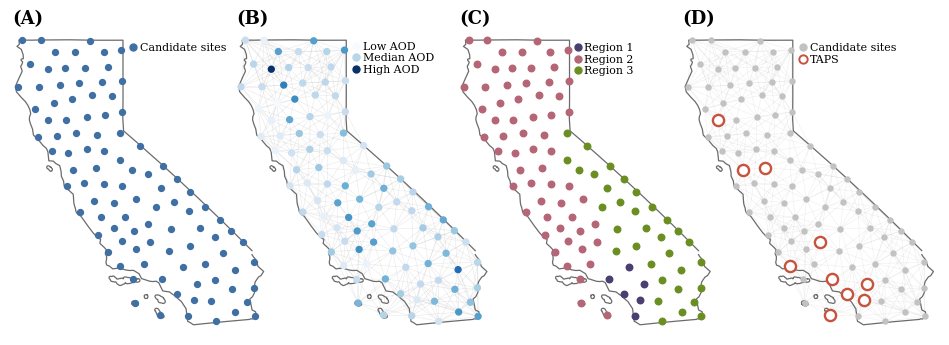

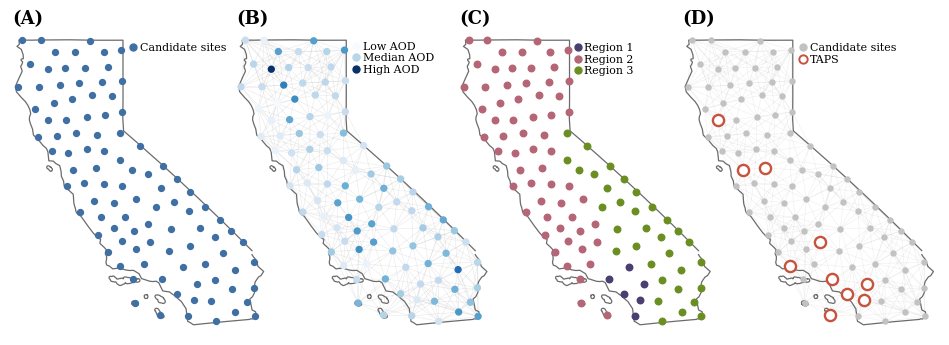

In [52]:
# Plot prospective pipeline
ca_outline = us_states["CA"]
ca_lons = np.array(ca_outline["lons"])
ca_lats = np.array(ca_outline["lats"])

plotsites = sites.to_crs(4326).reset_index()
plotsites["lon"] = plotsites.geometry.x
plotsites["lat"] = plotsites.geometry.y
meanaod = (
    data[data["distribution"].eq(PRIMARY)]
    .groupby("candidate")["aod055"]
    .mean()
    .reindex(ids)
    .to_numpy()
)

taps10 = np.asarray(ids)[np.asarray(taps_order[:BUDGET],dtype=int)]
selected = plotsites.set_index("candidate").loc[taps10]
edge_u,edge_v = np.where(np.triu(base["W"]>0,1))

site_color = "#3F6FA3"
edge_color = "#7F7F7F"
region_colors = ["#4B3F72","#B56576","#6B8E23"]
highlight_color = "#C6533E"
aod_cmap = "Blues"

def style_panel(ax):
    ax.plot(ca_lons,ca_lats,color="0.42",linewidth=.9,zorder=1)
    ax.set_xlim(-124.7,-113.9)
    ax.set_ylim(32.2,42.3)
    ax.set_aspect(1/np.cos(np.radians(37.0)),adjustable="box")
    ax.set_anchor("W")
    ax.axis("off")

def draw_edges(ax,lw,alpha):
    for u,v in zip(edge_u,edge_v):
        ax.plot(
            [plotsites.loc[u,"lon"],plotsites.loc[v,"lon"]],
            [plotsites.loc[u,"lat"],plotsites.loc[v,"lat"]],
            color=edge_color,
            linewidth=lw,
            alpha=alpha,
            zorder=2
        )

fig,axes = plt.subplots(1,4,figsize=(9.35,3.85),gridspec_kw={"wspace":-.14})
axA,axB,axC,axD = axes

legend_kwargs = dict(
    loc="upper right",
    frameon=False,
    borderaxespad=0.,
    handletextpad=.20,
    labelspacing=.14,
    handlelength=.75,
    fontsize=7.9
)

A_POS = (.85,.975)
B_POS = (.79,.980)
C_POS = (.70,.975)
D_POS = (.85,.975)

fig.subplots_adjust(left=.003,right=.997,top=.95,bottom=.06,wspace=-.14)

for ax in axes:
    style_panel(ax)

axA.scatter(plotsites["lon"],plotsites["lat"],s=18,color=site_color,zorder=3)
axA.text(.01,1.01,"(A)",transform=axA.transAxes,ha="left",va="bottom",fontweight="bold")
a_handle = Line2D([0],[0],marker="o",linestyle="",markerfacecolor=site_color,markeredgecolor=site_color,markersize=5,label="Candidate sites")
axA.legend(handles=[a_handle],bbox_to_anchor=A_POS,**legend_kwargs)

draw_edges(axB,.42,.16)
axB.scatter(plotsites["lon"],plotsites["lat"],c=meanaod,cmap=aod_cmap,s=18,zorder=3)
axB.text(.01,1.01,"(B)",transform=axB.transAxes,ha="left",va="bottom",fontweight="bold")
aod_min = float(np.nanmin(meanaod))
aod_mid = float(np.nanmedian(meanaod))
aod_max = float(np.nanmax(meanaod))
norm = plt.Normalize(aod_min,aod_max)
cmap = plt.get_cmap(aod_cmap)
b_handles = [
    Line2D([0],[0],marker="o",linestyle="",markerfacecolor=cmap(norm(value)),markeredgecolor=cmap(norm(value)),markersize=5,label=label)
    for value,label in [(aod_min,"Low AOD"),(aod_mid,"Median AOD"),(aod_max,"High AOD")]
]
axB.legend(handles=b_handles,bbox_to_anchor=B_POS,ncol=1,**legend_kwargs)

for band,color in zip([1,2,3],region_colors):
    mask = regionlabels==band
    axC.scatter(plotsites.loc[mask,"lon"],plotsites.loc[mask,"lat"],s=22,color=color,zorder=3)

axC.text(.01,1.01,"(C)",transform=axC.transAxes,ha="left",va="bottom",fontweight="bold")
c_handles = [
    Line2D([0],[0],marker="o",linestyle="",markerfacecolor=color,markeredgecolor=color,markersize=5,label=f"Region {band}")
    for band,color in zip([1,2,3],region_colors)
]
axC.legend(handles=c_handles,bbox_to_anchor=C_POS,ncol=1,**legend_kwargs)

draw_edges(axD,.38,.13)
axD.scatter(plotsites["lon"],plotsites["lat"],s=13,color="0.76",zorder=3)
axD.scatter(selected["lon"],selected["lat"],s=65,facecolors="white",edgecolors=highlight_color,linewidths=1.7,zorder=4)
axD.text(.01,1.01,"(D)",transform=axD.transAxes,ha="left",va="bottom",fontweight="bold")
d_handles = [
    Line2D([0],[0],marker="o",linestyle="",markerfacecolor="0.76",markeredgecolor="0.76",markersize=5,label="Candidate sites"),
    Line2D([0],[0],marker="o",linestyle="",markerfacecolor="white",markeredgecolor=highlight_color,markeredgewidth=1.4,markersize=6,label="TAPS")
]
axD.legend(handles=d_handles,bbox_to_anchor=D_POS,ncol=1,**legend_kwargs)

fig.savefig("pipeline.png",dpi=300,bbox_inches="tight",pad_inches=.04,facecolor="white")
plt.show()

In [53]:
# Summarize prospective design
summary = pd.DataFrame([
    ["primary_candidate_distribution",PRIMARY],
    ["hypothetical_candidates",len(ids)],
    ["environmental_windows",len(WINDOWS)],
    ["retained_dimension",K],
    ["effective_target_dimension",effdim],
    ["taps_risk_10",reference],
    ["reference_region_sizes","-".join(regionsaudit["candidates"].astype(str))],
    ["aod_missing_fraction",data["aod055"].isna().mean()],
    ["ground_monitor_pm25_used",False]
],columns=["result","value"])

display(summary)

,result,value
0,primary_candidate_distribution,stratified
1,hypothetical_candidates,100
2,environmental_windows,25
3,retained_dimension,30
4,effective_target_dimension,12
5,taps_risk_10,0.170584
6,reference_region_sizes,6-61-33
7,aod_missing_fraction,0.0055
8,ground_monitor_pm25_used,False


,result,value
0,primary_candidate_distribution,stratified
1,hypothetical_candidates,100
2,environmental_windows,25
3,retained_dimension,30
4,effective_target_dimension,12
5,taps_risk_10,0.170584
6,reference_region_sizes,6-61-33
7,aod_missing_fraction,0.0055
8,ground_monitor_pm25_used,False


In [54]:
# Export prospective results
shutil.rmtree(OUT,ignore_errors=True)
OUT.mkdir()

candidateparts = []
for frame in sets.values():
    export = frame.to_crs(4326).copy()
    export["longitude"] = export.geometry.x
    export["latitude"] = export.geometry.y
    candidateparts.append(export[["candidate","distribution","longitude","latitude","population","elevation"]])

candidates = pd.concat(candidateparts,ignore_index=True)

tables = {
    "protocol.csv":protocol,
    "sources.csv":sources,
    "candidate_summary.csv":candidateaudit,
    "candidates.csv":candidates,
    "signatures.csv":data,
    "graphs.csv":graphaudit,
    "target.csv":target.reset_index(),
    "regions.csv":regionsaudit,
    "summary.csv":summary
}

for name,frame in tables.items():
    frame.to_csv(OUT/name,index=False)

shutil.copy("pipeline.png",OUT/"pipeline.png")

np.savez_compressed(
    OUT/"model.npz",
    ids=np.asarray(ids),
    adjacency=base["W"],
    values=base["values"],
    vectors=base["vectors"],
    basis=base["basis"],
    target=base["weights"],
    g=base["g"],
    beta=np.asarray(base["beta"]),
    blocks=base["blocks"],
    taps=np.asarray(taps_order,dtype=int),
    labels=regionlabels,
    clock=base["clock"],
    horizon=np.asarray(base["horizon"])
)

print("CSV files:",len(list(OUT.glob("*.csv"))))
print("Pipeline saved:",(OUT/"pipeline.png").exists())
print("Model saved:",(OUT/"model.npz").exists())

CSV files: 9
Pipeline saved: True
Model saved: True
CSV files: 9
Pipeline saved: True
Model saved: True


In [55]:
# Archive prospective results
manifest = {
    "notebook":"07-prospective.ipynb",
    "purpose":"Prospective TAPS design from exogenous remotely sensed and environmental information",
    "region":REGION,
    "primary_candidate_distribution":PRIMARY,
    "candidate_count":COUNT,
    "candidate_distributions":KINDS,
    "environmental_years":[START,END],
    "season_months":MONTHS,
    "environmental_windows":len(WINDOWS),
    "graph_neighbors":NEIGHBORS,
    "graph_connectivity":"symmetric geographic kNN plus geographic MST",
    "aerosol_source":AOD,
    "meteorology_source":ERA,
    "population_source":POP,
    "elevation_source":ELEV,
    "landcover_source":LAND,
    "ground_monitor_pm25_used":False,
    "retained_dimension":K,
    "observation_normalized":CLOCK.tolist(),
    "target_normalized_horizon":HORIZON,
    "beta_scale":BSCALE,
    "sensor_budget":BUDGET,
    "max_budget":MAXBUDGET,
    "seed":SEED,
    "access_date_utc":ACCESS,
    "taps_ten_sensor_risk":float(reference),
    "paper_figure":"pipeline.png",
    "blind_followup":"10-blind.ipynb"
}

with open(OUT/"manifest.json","w") as file:
    json.dump(manifest,file,indent=2)

archive = Path("07-prospective.zip")
if archive.exists():
    archive.unlink()

with zipfile.ZipFile(archive,"w",compression=zipfile.ZIP_DEFLATED) as zipped:
    for path in sorted(OUT.iterdir()):
        zipped.write(path,arcname=path.name)

with zipfile.ZipFile(archive) as zipped:
    members = zipped.namelist()
    bad = zipped.testzip()

    for name in members:
        if name.endswith(".csv"):
            with zipped.open(name) as file:
                pd.read_csv(file)

archiveaudit = pd.DataFrame({
    "metric":["archive_members","csv_files","corrupt_member","manifest","model","pipeline"],
    "value":[
        len(members),
        sum(name.endswith(".csv") for name in members),
        bad,
        "manifest.json" in members,
        "model.npz" in members,
        "pipeline.png" in members
    ]
})

display(archiveaudit)
files.download(str(archive))

,metric,value
0,archive_members,12
1,csv_files,9
2,corrupt_member,None
3,manifest,True
4,model,True
5,pipeline,True


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,metric,value
0,archive_members,12
1,csv_files,9
2,corrupt_member,None
3,manifest,True
4,model,True
5,pipeline,True


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>